# 03 — Visualizaciones

Genera las 4 gráficas del tablero a partir de los CSV de análisis.
Guarda los HTML en `dashboard/` con Plotly cargado desde CDN
(archivos pequeños, aptos para el repo).

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import os
from pathlib import Path

RAIZ          = Path('..').resolve()
RUTA_ANALISIS = RAIZ / 'datos' / 'analisis'
RUTA_DASH     = RAIZ / 'dashboard'
RUTA_SALIDA   = RAIZ / 'datos' / 'analisis'

RUTA_DASH.mkdir(parents=True, exist_ok=True)

COLOR_HOMBRE = '#378ADD'
COLOR_MUJER  = '#D4537E'
COLOR_MAPA   = {'Hombre': COLOR_HOMBRE, 'Mujer': COLOR_MUJER}

sn  = pd.read_csv(RUTA_ANALISIS / 'serie_nacional.csv',           encoding='utf-8-sig')
bs  = pd.read_csv(RUTA_ANALISIS / 'brecha_sector_anio.csv',        encoding='utf-8-sig')

# Detectar el archivo de brecha educativa (tiene el año en el nombre)
archivo_educ = next(RUTA_ANALISIS.glob('brecha_educ_sector_*.csv'), None)
archivo_inf  = next(RUTA_ANALISIS.glob('informalidad_contexto_*.csv'), None)

if not archivo_educ or not archivo_inf:
    raise FileNotFoundError('Faltan archivos en datos/analisis/. Corre 02_calculo.ipynb primero.')

be  = pd.read_csv(archivo_educ, encoding='utf-8-sig')
inf = pd.read_csv(archivo_inf,  encoding='utf-8-sig')

pivot_sn = sn.pivot(index='anio', columns='sexo', values='mediana_ing_hora').reset_index()
pivot_sn['brecha_pct'] = ((pivot_sn['Hombre'] - pivot_sn['Mujer']) / pivot_sn['Hombre'] * 100).round(1)

print(f'Datos cargados OK. Último año disponible: {sn["anio"].max()}')

Datos cargados OK. Último año disponible: 2025


## G1 — Tendencia nacional 2005–2025

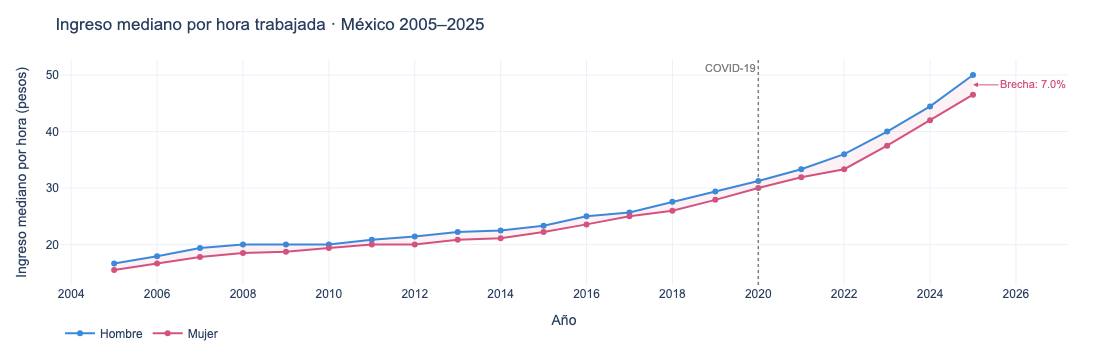

G1 guardada.


In [2]:
hombre = sn[sn['sexo']=='Hombre'].sort_values('anio')
mujer  = sn[sn['sexo']=='Mujer'].sort_values('anio')

fig1 = px.line(
    sn, x='anio', y='mediana_ing_hora', color='sexo',
    color_discrete_map=COLOR_MAPA, markers=True,
    labels={'anio':'Año','mediana_ing_hora':'Ingreso mediano por hora (pesos)','sexo':''},
    title='Ingreso mediano por hora trabajada · México 2005–2025',
)

# Área sombreada entre las dos líneas
fig1.add_trace(go.Scatter(
    x=list(hombre['anio']) + list(hombre['anio'])[::-1],
    y=list(hombre['mediana_ing_hora']) + list(mujer['mediana_ing_hora'])[::-1],
    fill='toself', fillcolor='rgba(212,83,126,0.08)',
    line=dict(color='rgba(255,255,255,0)'), showlegend=False, hoverinfo='skip',
))

fig1.add_vline(x=2020, line_dash='dot', line_color='gray', line_width=1.5,
               annotation_text='COVID-19', annotation_position='top left',
               annotation_font=dict(size=11, color='gray'))

ultimo = pivot_sn[pivot_sn['anio'] == pivot_sn['anio'].max()].iloc[0]
fig1.add_annotation(
    x=ultimo['anio'], y=(ultimo['Hombre'] + ultimo['Mujer']) / 2,
    text=f"Brecha: {ultimo['brecha_pct']}%",
    showarrow=True, arrowhead=2, ax=60, ay=0,
    font=dict(size=11, color=COLOR_MUJER), arrowcolor=COLOR_MUJER,
)

fig1.update_layout(
    template='plotly_white', hovermode='x unified',
    legend=dict(orientation='h', y=-0.15),
    xaxis=dict(dtick=2), margin=dict(t=60, b=60, l=60, r=40),
    font=dict(family='Arial, sans-serif', size=12),
)

# include_plotlyjs='cdn' hace el HTML pequeño (~20 KB en vez de 4.4 MB)
fig1.write_html(str(RUTA_DASH / 'g1_serie_nacional.html'), include_plotlyjs='cdn')
fig1.show()
print('G1 guardada.')

## G2 — Brecha salarial por sector

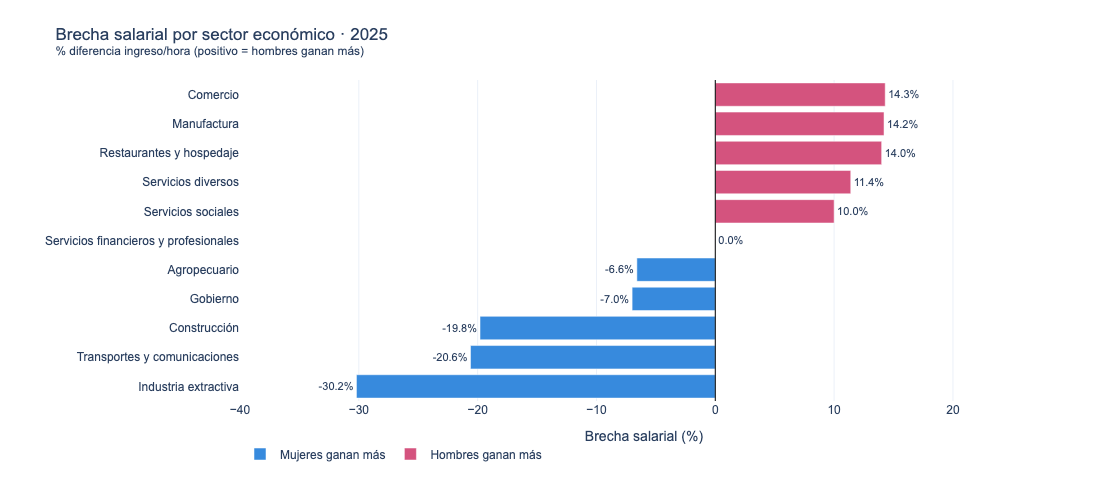

G2 guardada.


In [3]:
anio_max = int(bs['anio'].max())
bs25 = bs[bs['anio'] == anio_max].sort_values('brecha_pct', ascending=True).copy()
bs25['color_barra'] = bs25['brecha_pct'].apply(
    lambda x: 'Hombres ganan más' if x > 0 else 'Mujeres ganan más'
)

fig2 = px.bar(
    bs25, x='brecha_pct', y='sector', color='color_barra',
    color_discrete_map={'Hombres ganan más': COLOR_MUJER, 'Mujeres ganan más': COLOR_HOMBRE},
    orientation='h', text='brecha_pct',
    labels={'brecha_pct':'Brecha salarial (%)','sector':'','color_barra':''},
    title=f'Brecha salarial por sector económico · {anio_max}<br>'
          f'<sup>% diferencia ingreso/hora (positivo = hombres ganan más)</sup>',
)
fig2.update_traces(texttemplate='%{text:.1f}%', textposition='outside', textfont=dict(size=11))
fig2.add_vline(x=0, line_color='black', line_width=1)
fig2.update_layout(
    template='plotly_white', legend=dict(orientation='h', y=-0.12),
    xaxis=dict(zeroline=False, range=[-40, 28]),
    margin=dict(t=80, b=60, l=240, r=60), height=480,
    font=dict(family='Arial, sans-serif', size=12),
)

fig2.write_html(str(RUTA_DASH / 'g2_brecha_sector.html'), include_plotlyjs='cdn')
fig2.show()
print('G2 guardada.')

## G3 — Heatmap: brecha por sector y nivel educativo

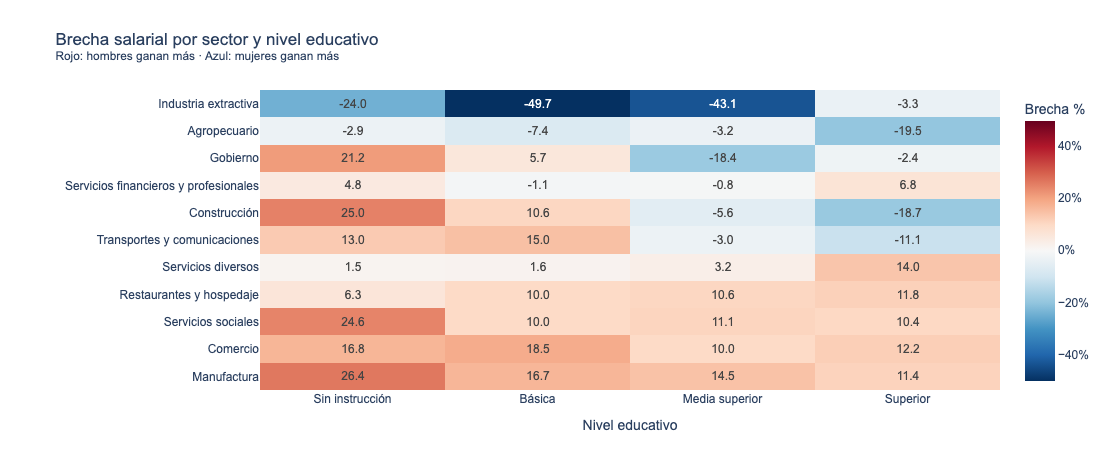

G3 guardada.


In [4]:
be_clean = be[be['nivel_educ'] != 'No especificado'].copy()
orden_educ = ['Sin instrucción','Básica','Media superior','Superior']
be_clean['nivel_educ'] = pd.Categorical(be_clean['nivel_educ'], categories=orden_educ, ordered=True)

hm = be_clean.pivot_table(index='sector', columns='nivel_educ', values='brecha_pct')
hm['_media'] = hm.mean(axis=1)
hm = hm.sort_values('_media', ascending=True).drop(columns='_media')

fig3 = px.imshow(
    hm, color_continuous_scale='RdBu_r', color_continuous_midpoint=0,
    text_auto='.1f', labels={'color':'Brecha (%)'},
    title='Brecha salarial por sector y nivel educativo<br>'
          '<sup>Rojo: hombres ganan más · Azul: mujeres ganan más</sup>',
    aspect='auto',
)
fig3.update_layout(
    template='plotly_white', xaxis_title='Nivel educativo', yaxis_title='',
    coloraxis_colorbar=dict(title='Brecha %', ticksuffix='%'),
    margin=dict(t=90, b=60, l=260, r=60), height=450,
    font=dict(family='Arial, sans-serif', size=12),
)

fig3.write_html(str(RUTA_DASH / 'g3_heatmap_educ_sector.html'), include_plotlyjs='cdn')
fig3.show()
print('G3 guardada.')

## G4 — Ingreso por hora con informalidad como contexto

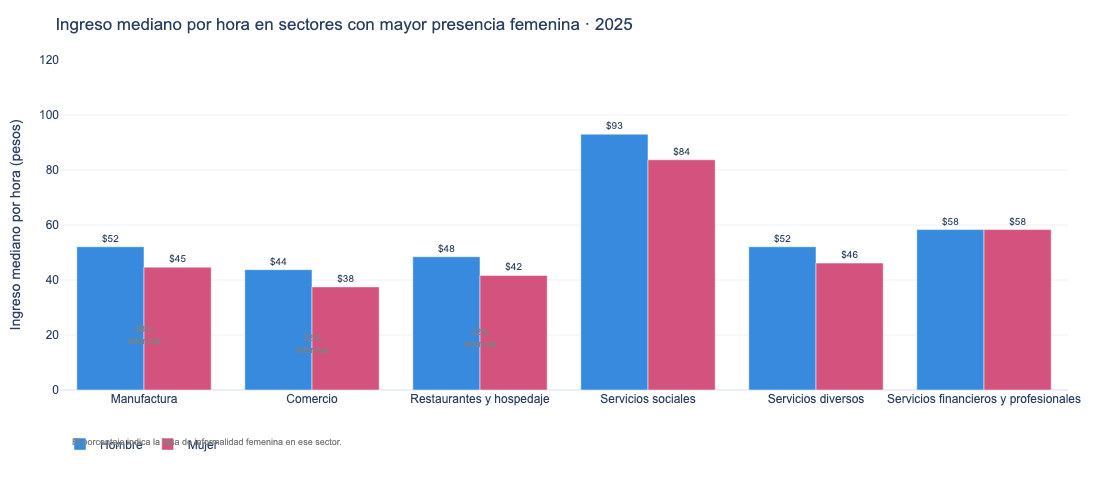

G4 guardada.


In [5]:
sectores_enfoque = [
    'Manufactura','Comercio','Restaurantes y hospedaje',
    'Servicios sociales','Servicios diversos','Servicios financieros y profesionales',
]

bs_focus = bs[bs['anio'] == anio_max].copy()
bs_focus = bs_focus[bs_focus['sector'].isin(sectores_enfoque)]

bs_long = bs_focus.melt(
    id_vars=['sector','brecha_pct'], value_vars=['Hombre','Mujer'],
    var_name='sexo', value_name='ingreso_hora'
).sort_values(['brecha_pct','sexo'], ascending=[False, True])

fig4 = px.bar(
    bs_long, x='sector', y='ingreso_hora', color='sexo',
    barmode='group', color_discrete_map=COLOR_MAPA, text='ingreso_hora',
    labels={'ingreso_hora':'Ingreso mediano por hora (pesos)','sector':'','sexo':''},
    title=f'Ingreso mediano por hora en sectores con mayor presencia femenina · {anio_max}',
    category_orders={'sector': sectores_enfoque},
)
fig4.update_traces(texttemplate='$%{text:.0f}', textposition='outside', textfont=dict(size=10))

# Informalidad femenina como anotación de contexto
inf_mujeres = inf[inf['sexo'] == 'Mujer'].set_index('sector')
for sector in ['Manufactura','Comercio','Restaurantes y hospedaje']:
    if sector in inf_mujeres.index:
        pct   = inf_mujeres.loc[sector, 'pct_informalidad']
        ing_m = bs_long[(bs_long['sector'] == sector) & (bs_long['sexo'] == 'Mujer')]['ingreso_hora'].values
        if len(ing_m) > 0:
            fig4.add_annotation(
                x=sector, y=ing_m[0] * 0.45,
                text=f'{pct:.0f}%<br>informal',
                showarrow=False, font=dict(size=9, color='gray'), align='center',
            )

fig4.add_annotation(
    xref='paper', yref='paper', x=0.01, y=-0.18,
    text='El porcentaje indica la tasa de informalidad femenina en ese sector.',
    showarrow=False, font=dict(size=9, color='gray'), xanchor='left',
)
fig4.update_layout(
    template='plotly_white', legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=90, l=60, r=40), height=480, yaxis=dict(range=[0, 120]),
    font=dict(family='Arial, sans-serif', size=12),
)

fig4.write_html(str(RUTA_DASH / 'g4_ingreso_sector_informalidad.html'), include_plotlyjs='cdn')
fig4.show()
print('G4 guardada.')

In [6]:
print(f'Gráficas guardadas en {RUTA_DASH}:')
for f in sorted(RUTA_DASH.glob('*.html')):
    kb = f.stat().st_size / 1024
    print(f'  {f.name:<45}  {kb:.0f} KB')

Gráficas guardadas en /Users/mateos_kvn/HackODS26/LoboEnsambladores/dashboard:
  g1_serie_nacional.html                         10 KB
  g2_brecha_sector.html                          9 KB
  g3_heatmap_educ_sector.html                    9 KB
  g4_ingreso_sector_informalidad.html            10 KB


---
## Gráficas adicionales recomendadas

Las siguientes gráficas profundizan lo que G1–G4 muestran en la superficie.


| Gráfica | Pregunta que responde | Por qué importa |
|---------|----------------------|-----------------|
| G5 — Evolución de brecha por sector | ¿En qué sectores la brecha se cerró, se mantuvo o se amplió? | G2 solo muestra 2025; esto muestra el movimiento |
| G6 — Scatter brecha vs informalidad | ¿Los sectores con más informalidad femenina tienen mayor brecha? | Conecta las dos dimensiones que G2 y G4 muestran por separado |
| G7 — Pirámide poblacional por sector | ¿Cuántas personas representan esas brechas? | Da peso real a los hallazgos |
| G8 — Brecha estructural: mismo cargo, misma escolaridad | ¿Sigue habiendo brecha cuando el cargo y el título son iguales? | Es la pregunta más profunda — usa el CSV de la sección 8 |

In [7]:
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

RUTA_DASH = RAIZ / 'dashboard'
RUTA_DASH.mkdir(parents=True, exist_ok=True)

COLOR_HOMBRE = '#378ADD'
COLOR_MUJER  = '#D4537E'
COLOR_MAPA   = {'Hombre': COLOR_HOMBRE, 'Mujer': COLOR_MUJER}

print('Librerías listas para las gráficas adicionales.')

Librerías listas para las gráficas adicionales.


### G5 — Evolución de la brecha por sector (2005–2025)

Responde qué sectores cerraron la brecha y cuáles la ampliaron.
Se filtra a los 4 sectores más relevantes para no saturar la gráfica.

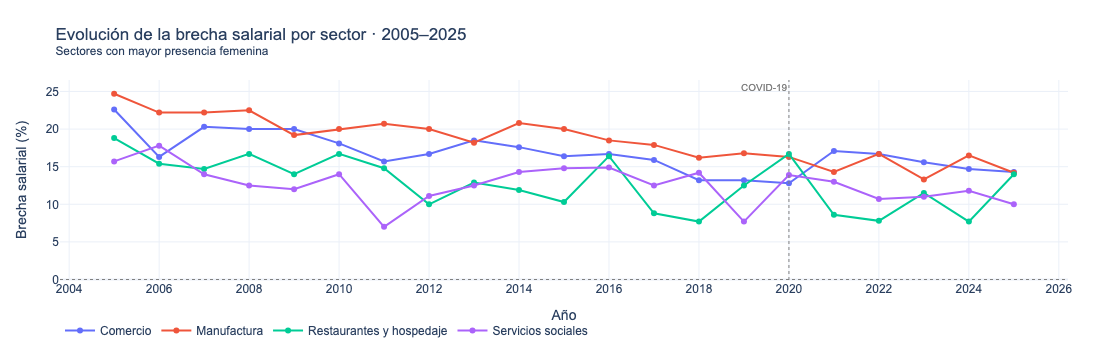

G5 guardada.


In [8]:
# Recargar brecha por sector para tener todos los años
bp_full = pd.read_csv(RUTA_SALIDA/'brecha_sector_anio.csv', encoding='utf-8-sig')

# Sectores con mayor presencia femenina y brecha consistente
sectores_g5 = ['Manufactura','Comercio','Restaurantes y hospedaje','Servicios sociales']
bp_g5 = bp_full[bp_full['sector'].isin(sectores_g5)].copy()

fig5 = px.line(
    bp_g5, x='anio', y='brecha_pct', color='sector',
    markers=True,
    labels={'anio':'Año','brecha_pct':'Brecha salarial (%)','sector':''},
    title='Evolución de la brecha salarial por sector · 2005–2025<br>'
          '<sup>Sectores con mayor presencia femenina</sup>',
)
fig5.add_hline(y=0, line_dash='dot', line_color='gray', line_width=1)
fig5.add_vline(x=2020, line_dash='dot', line_color='gray', line_width=1,
               annotation_text='COVID-19', annotation_position='top left',
               annotation_font=dict(size=10, color='gray'))
fig5.update_layout(
    template='plotly_white', hovermode='x unified',
    legend=dict(orientation='h', y=-0.18),
    xaxis=dict(dtick=2), margin=dict(t=80, b=80, l=60, r=40),
    font=dict(family='Arial, sans-serif', size=12),
)
fig5.write_html(str(RUTA_DASH/'g5_evolucion_brecha_sector.html'), include_plotlyjs='cdn')
fig5.show()
print('G5 guardada.')

### G6 — Scatter: ¿más informalidad femenina = mayor brecha?

Cada punto es un sector. Conecta las dos dimensiones que G2 y G4 muestran por separado.
Si hay correlación positiva, confirma que la informalidad y la brecha van juntas.

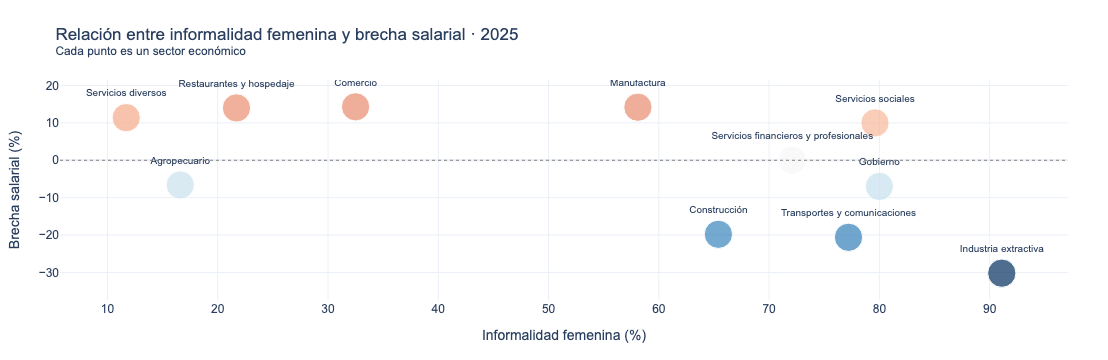

G6 guardada.


In [12]:
inf_df   = pd.read_csv(next(RUTA_SALIDA.glob('informalidad_contexto_*.csv')), encoding='utf-8-sig')
#brecha25 = bp_full[bp_full['anio'] == ult][['sector','brecha_pct']].copy()
brecha25 = bp_full[bp_full['anio'] == anio_max][['sector','brecha_pct']].copy()

inf_muj = inf_df[inf_df['sexo']=='Mujer'].rename(columns={'pct_informalidad':'inf_mujer'})
inf_hom = inf_df[inf_df['sexo']=='Hombre'].rename(columns={'pct_informalidad':'inf_hombre'})

scatter_df = brecha25.merge(inf_muj[['sector','inf_mujer']], on='sector')
scatter_df = scatter_df.merge(inf_hom[['sector','inf_hombre']], on='sector')
scatter_df['diff_informalidad'] = (scatter_df['inf_mujer'] - scatter_df['inf_hombre']).round(1)

fig6 = px.scatter(
    scatter_df, x='inf_mujer', y='brecha_pct',
    text='sector', size=[20]*len(scatter_df),
    color='brecha_pct',
    color_continuous_scale='RdBu_r', color_continuous_midpoint=0,
    labels={
        'inf_mujer'  : 'Informalidad femenina (%)',
        'brecha_pct' : 'Brecha salarial (%)',
    },
    title=f'Relación entre informalidad femenina y brecha salarial · {anio_max}<br>'
          '<sup>Cada punto es un sector económico</sup>',
)
fig6.update_traces(textposition='top center', textfont=dict(size=10))
fig6.add_hline(y=0, line_dash='dot', line_color='gray', line_width=1)
fig6.update_layout(
    template='plotly_white',
    coloraxis_showscale=False,
    margin=dict(t=80, b=60, l=60, r=40),
    font=dict(family='Arial, sans-serif', size=12),
)
fig6.write_html(str(RUTA_DASH/'g6_scatter_informalidad_brecha.html'), include_plotlyjs='cdn')
fig6.show()
print('G6 guardada.')

### G7 — Pirámide poblacional por sector

Muestra cuántas personas (expandidas con fac_tri) representa cada sector,
desagregadas por sexo. Da peso real a los hallazgos de brecha:
un sector con mucha brecha pero poca población tiene menos impacto social.

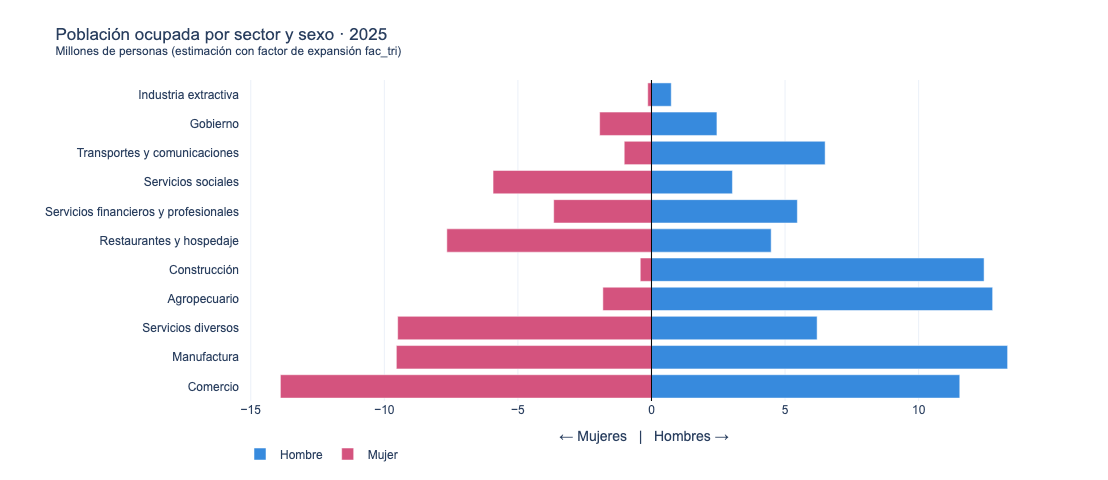

G7 guardada.


In [15]:
archivo_ocup = next(RUTA_ANALISIS.glob('brecha_sector_ocupacion_*.csv'), None)
if not archivo_ocup:
    raise FileNotFoundError('Corre la sección 8 del 02_calculo primero.')

df_ocup  = pd.read_csv(archivo_ocup, encoding='utf-8-sig')
anio_ult = int(df_ocup['anio'].max())

pob = df_ocup[df_ocup['anio']==anio_ult].groupby(['sector','sexo'])['poblacion_ocupada'].sum().reset_index()
pob['millones']   = (pob['poblacion_ocupada'] / 1_000_000).round(2)
pob['valor_graf'] = pob.apply(lambda r: -r['millones'] if r['sexo']=='Mujer' else r['millones'], axis=1)

orden = pob.groupby('sector')['millones'].sum().sort_values(ascending=True).index.tolist()

fig7 = px.bar(
    pob, x='valor_graf', y='sector', color='sexo',
    color_discrete_map=COLOR_MAPA, orientation='h',
    labels={'valor_graf':'Millones de personas','sector':'','sexo':''},
    title=f'Población ocupada por sector y sexo · {anio_ult}<br>'
          '<sup>Millones de personas (estimación con factor de expansión fac_tri)</sup>',
    category_orders={'sector': orden},
)
fig7.add_vline(x=0, line_color='black', line_width=1)
fig7.update_layout(
    template='plotly_white', barmode='relative',
    legend=dict(orientation='h', y=-0.12),
    xaxis_title='← Mujeres   |   Hombres →',
    margin=dict(t=80, b=60, l=240, r=60), height=480,
    font=dict(family='Arial, sans-serif', size=12),
)
fig7.write_html(str(RUTA_DASH / 'g7_piramide_poblacion_sector.html'), include_plotlyjs='cdn')
fig7.show()
print('G7 guardada.')

### G8 — Brecha estructural: mismo cargo y misma escolaridad

Usa la tabla de la sección 8 para mostrar los casos donde
hombres y mujeres con el mismo tipo de ocupación y nivel educativo
ganan diferente dentro del mismo sector.

Se filtra a combinaciones donde hay al menos 5,000 personas de cada sexo
para evitar que grupos muy pequeños dominen la vista.

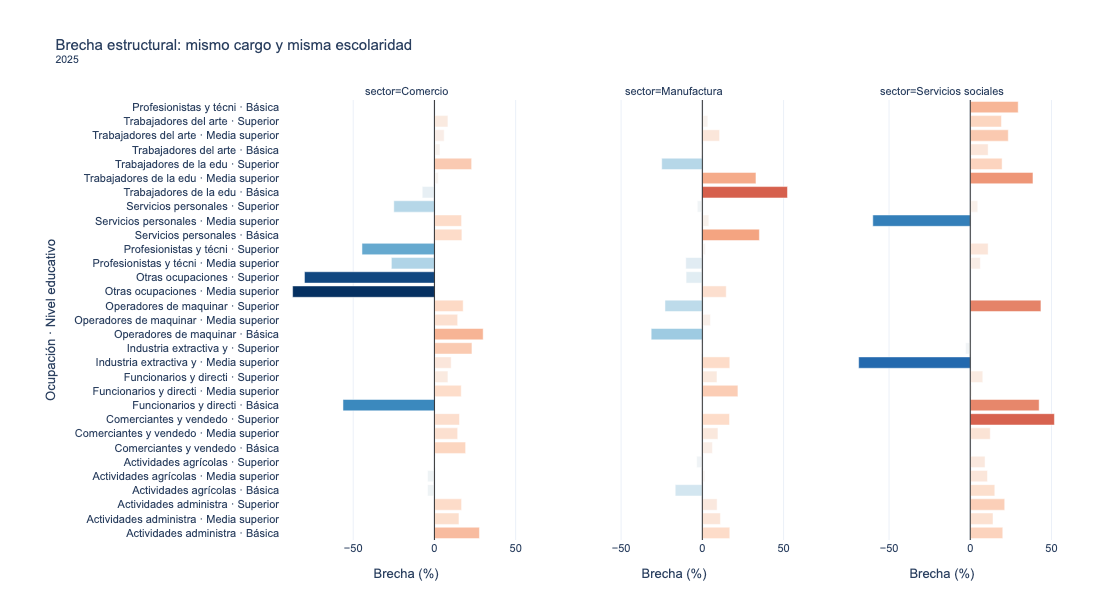

G8 guardada.


In [16]:
archivo_est = next(RUTA_ANALISIS.glob('brecha_estructural_*.csv'), None)
if not archivo_est:
    raise FileNotFoundError('Corre la sección 9 del 02_calculo primero.')

pivot_ext = pd.read_csv(archivo_est, encoding='utf-8-sig')
anio_ult  = int(archivo_est.stem.split('_')[-1])

sectores_g8    = ['Manufactura','Comercio','Servicios sociales']
niveles_validos = ['Básica','Media superior','Superior']

df_g8 = pivot_ext[
    pivot_ext['sector'].isin(sectores_g8) &
    pivot_ext['nivel_educ'].isin(niveles_validos) &
    pivot_ext['brecha_pct'].notna()
].dropna(subset=['Hombre','Mujer']).copy()

df_g8['etiqueta'] = df_g8['ocupacion'].str[:22] + ' · ' + df_g8['nivel_educ']

fig8 = px.bar(
    df_g8, x='brecha_pct', y='etiqueta',
    facet_col='sector', facet_col_wrap=3,
    color='brecha_pct',
    color_continuous_scale='RdBu_r', color_continuous_midpoint=0,
    orientation='h',
    labels={'brecha_pct':'Brecha (%)','etiqueta':'Ocupación · Nivel educativo'},
    title='Brecha estructural: mismo cargo y misma escolaridad<br>'
          f'<sup>{anio_ult}</sup>',
)
fig8.add_vline(x=0, line_color='black', line_width=0.8)
fig8.update_coloraxes(showscale=False)
fig8.update_layout(
    template='plotly_white',
    margin=dict(t=100, b=60, l=280, r=40), height=600,
    font=dict(family='Arial, sans-serif', size=11),
)
fig8.write_html(str(RUTA_DASH / 'g8_brecha_estructural.html'), include_plotlyjs='cdn')
fig8.show()
print('G8 guardada.')